# Electricity Cost Prediction Dataset

---

## Sobre o Conjunto de Dados

Este conjunto de dados, intitulado "Powering Predictions: Unveiling the Dynamics of Electricity Costs in Modern Infrastructure" (Fortalecendo Previsões: Revelando a Dinâmica dos Custos de Eletricidade em Infraestruturas Modernas), fornece uma coleção realista e abrangente de 10.000 pontos de dados projetados para previsão de custos de eletricidade. Ele abrange uma variedade de fatores que influenciam o consumo e as despesas de energia em diferentes tipos de locais. O conjunto de dados inclui as seguintes colunas principais:

- ***Site Area (square meters)*** Área do Local (metros quadrados): Representa o tamanho físico do imóvel, um dos principais impulsionadores das necessidades energéticas.
- ***Structure Type*** Tipo de Estrutura: Categoriza o imóvel em "Residencial", "Comercial", "Uso Misto" ou "Industrial", refletindo diversos padrões operacionais e de consumo.
- ***Water Consumption (liters/day)*** Consumo de Água (litros/dia): Um indicador indireto do uso de energia, especialmente para aquecimento e bombeamento de água.
- ***Recycling Rate (%)*** Taxa de Reciclagem (%): Sugere a consciência ambiental e as potenciais práticas de eficiência energética do local.
- ***Utilisation Rate (%)*** Taxa de Utilização (%): Indica a intensidade operacional e o uso da capacidade, impactando diretamente a demanda de energia.
- ***Air Quality Index (AQI)*** Índice de Qualidade do Ar (IQA): Pode influenciar o consumo de energia por meio do uso do sistema HVAC para manter a qualidade do ar interno.
- ***Issue Resolution Time (hours)*** Tempo de Resolução de Problemas (horas): Um indicador da eficiência operacional; tempos de resolução mais longos podem estar relacionados ao desperdício de energia.
- ***Resident Count (number of people)*** Contagem de Residentes (número de pessoas): Um fator significativo para propriedades residenciais e de uso misto, afetando diretamente o consumo de eletricidade.
- ***Electricity Cost (USD/month)*** Custo de Eletricidade (USD/mês): A variável-alvo, que representa o gasto mensal com eletricidade, influenciada por todos os outros parâmetros.

Cada ponto de dados foi cuidadosamente gerado para garantir realismo e credibilidade, com valores dentro das faixas nominais e esperadas para cada coluna respectiva. As relações entre colunas foram modeladas para refletir cenários do mundo real, tornando este conjunto de dados adequado para o desenvolvimento e teste de modelos robustos de previsão de custos de eletricidade.

Link dataset Kaggle: https://www.kaggle.com/datasets/shalmamuji/electricity-cost-prediction-dataset/data?select=electricity_cost_dataset.csv

---
## Objetivos:

Utilizar a base de dados para exercicitar praticas de manipulação de dados, tratamento de dados, modelos de ML para regressão, metricas de desempenho do Modelo entre outras melhorias.

- Análise Exploratória
- Visualizações Gráficas
- Tratamento dos Dados (se necessário)
- Implementação Regressão Linear para previsão da Variável "electricity cost"
    - Metricas de Avaliação 
    - Visualizações Graficas das metricas


---
## 1 - Importação das bibliotecas e Análise Exploratória

In [ ]:
#Bibliotecas para manipulação e visualizações gráficas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Bbiliotecas para modelos de Regressão
from sklearn.linear_model import LinearRegression

#Bibliotecas para divisão e metricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [3]:
#Leitura do csv e criação do DF
df_original = pd.read_csv('electricity_cost_dataset.csv')

#Leitura do head do DF
df_original.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [4]:
#Verifica valores nulos
df_original.isnull().sum()

site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64

In [5]:
#Verifica linhas duplicas
df_original.duplicated().sum()

np.int64(0)

In [ ]:
#Verifica tamanho do DF
df_original.shape()

(10000, 9)

In [7]:
#Verifica informacoes/ tipos de dados
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  object 
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


In [ ]:
#Verifica valores unicos na coluna textual
df_original['structure type'].unique()

array(['Mixed-use', 'Residential', 'Commercial', 'Industrial'],
      dtype=object)

A coluna representa o tipo de imovel, isso reflete diretamente uma hierarquia para o consumo de energia. Visto que o setor industrial tem um consumo maior que um residencial. Possivel indicativo de tratamento com ordem hierarquica.

---
## 2 - Visualizações Graficas

In [13]:
#Dividir a base, entre variaveis categoricas e numericas
num_vars = df_original.select_dtypes(['int64', 'float64'])
categ_vars = df_original.select_dtypes(['object'])

### 2.1 - Boxplot

Permite visualizar distribuicao das variaveis numericas, identificar possiveis outliers.

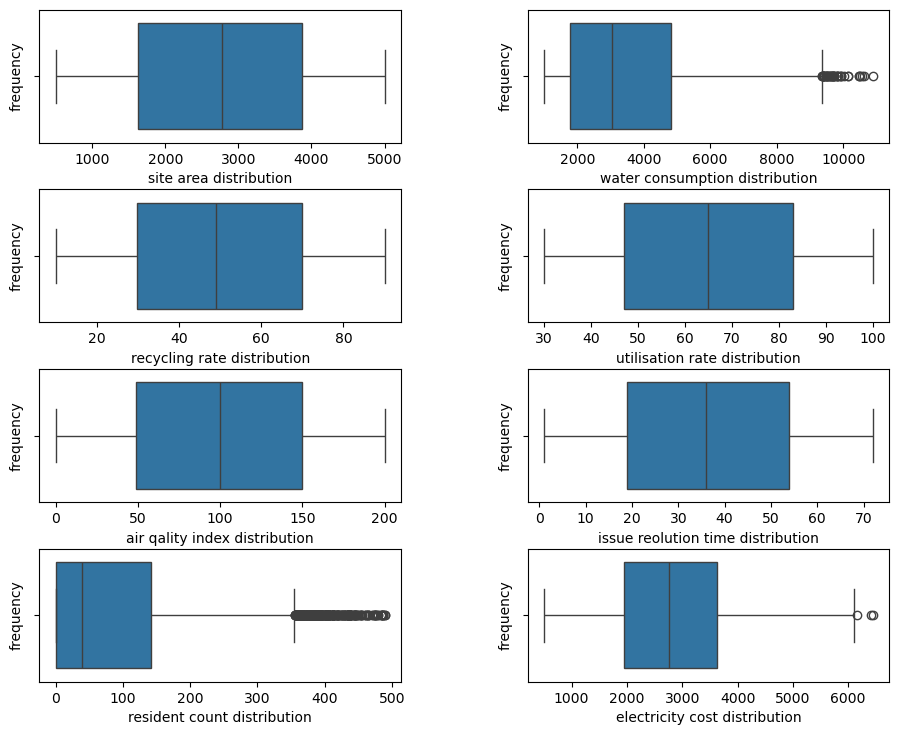

In [17]:
#Defini tamanho do grafico
plt.figure(figsize=(10, 8))

#Grafico boxplot
#Grafico de BoxPlot
for i, col in enumerate(num_vars):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.boxplot(data=df_original, x=col)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()


### 2.2 - Violinplot

Um grafico de violino desempenha um papel semelhante ao grafico Boxplot. Ele mostra a distribuição dos pontos de dados após o agrupamento por uma (ou mais) variáveis. Ao contrário de um boxplot, cada violino é desenhado usando uma estimativa de densidade de kernel da distribuição subjacente

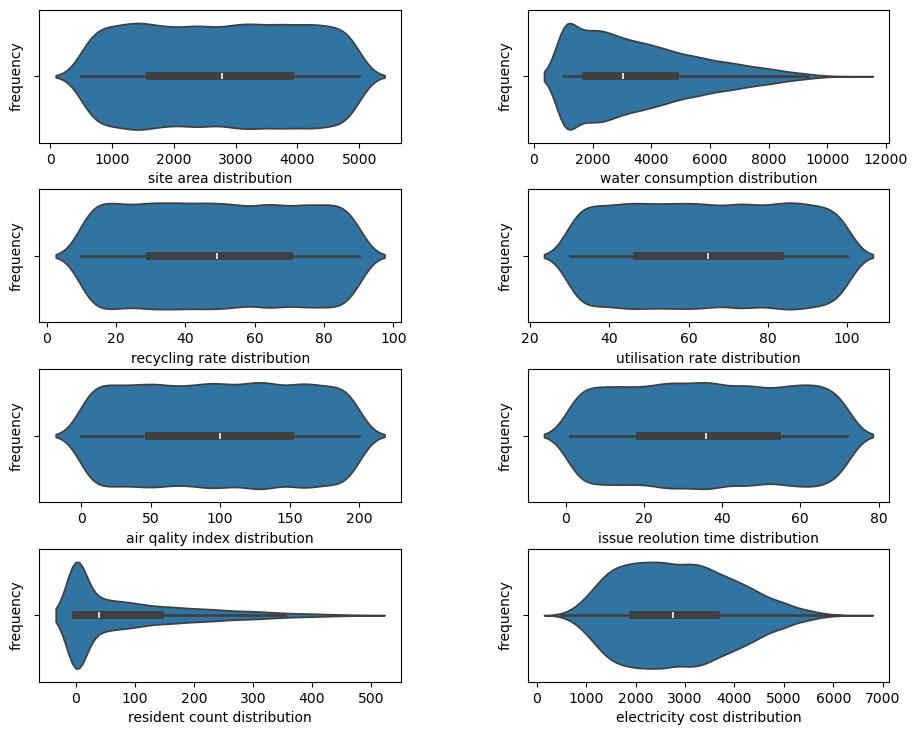

In [19]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 8))

#Grafico de BoxPlot
for i, col in enumerate(num_vars):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.violinplot(data=df_original, x=col)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

### 2.3 - Histplot

Um histplot é uma ferramenta de visualização clássica que representa a distribuição de uma ou mais variáveis ​​contando o número de observações que se enquadram em compartimentos discretos.

Esta função pode normalizar a estatística calculada dentro de cada bin para estimar frequência, densidade ou massa de probabilidade, e pode adicionar uma curva suave obtida usando uma estimativa de densidade de kernel, semelhante a kdeplot().

In [ ]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 12))

#Grafico de BoxPlot
for i, col in enumerate(va):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.histplot(data=df_original, x=col, kde=True)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()